Dataset Shape: (442, 10)

Model Performance:
            Model     MAE       MSE    RMSE     R2
Linear Regression 42.7941 2900.1936 53.8534 0.4526
 Ridge Regression 42.8120 2892.0146 53.7775 0.4541
 Lasso Regression 42.8052 2884.6243 53.7087 0.4555
    Decision Tree 47.0454 3568.9653 59.7408 0.3264
    Random Forest 44.4154 2980.5415 54.5943 0.4374

Best Model:
Lasso Regression


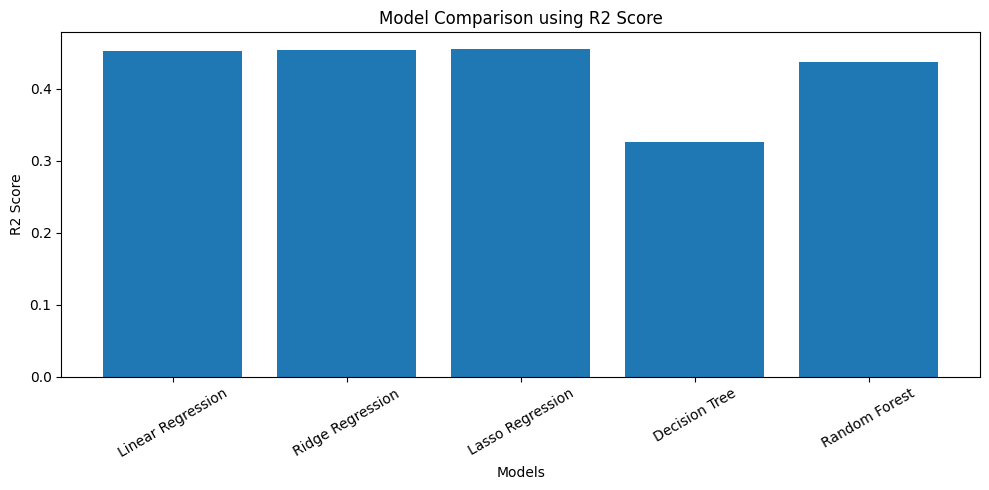

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Load Diabetes dataset
data = load_diabetes(as_frame=True)

X = data.data
y = data.target

print("Dataset Shape:", X.shape)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Standardize features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create regression models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=4,
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )
}

results = []

# Train and evaluate models
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append([
        name,
        mae,
        mse,
        rmse,
        r2
    ])

# Display results
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MSE", "RMSE", "R2"]
)

print("\nModel Performance:")
print(results_df.round(4).to_string(index=False))

# Find best model
best_model = results_df.loc[
    results_df["R2"].idxmax()
]

print("\nBest Model:")
print(best_model["Model"])

# Model comparison graph
plt.figure(figsize=(10, 5))

plt.bar(
    results_df["Model"],
    results_df["R2"]
)

plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison using R2 Score")

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

Normal Equation
Test MSE: 2900.1936284934823
Test R2: 0.45260276297191926

Batch Gradient Descent
Test MSE: 2887.5022583362106
Test R2: 0.45499819646640627

Mini-batch Gradient Descent
Test MSE: 3314.2323424748197
Test R2: 0.37445499868841003

Stochastic Gradient Descent
Test MSE: 2754.393027679174
Test R2: 0.48012190695550383


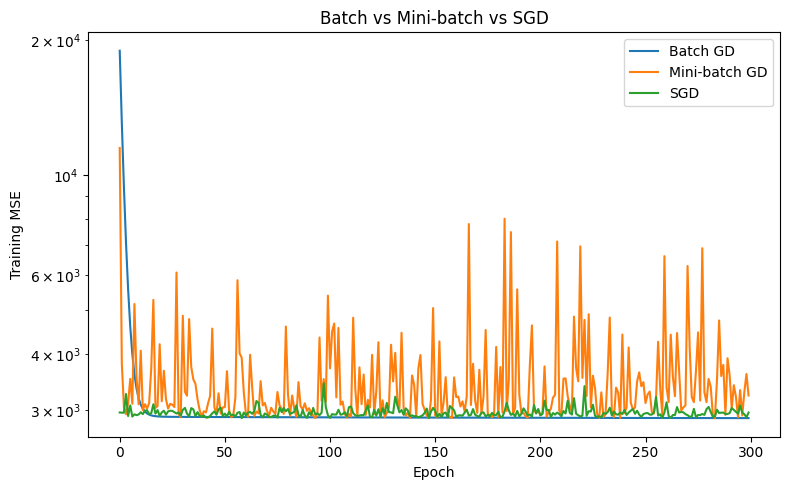

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error, r2_score


# Load Diabetes dataset
data = load_diabetes()

X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Standardize features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Add bias column
def add_bias(X):
    return np.c_[
        np.ones(X.shape[0]),
        X
    ]


X_train = add_bias(X_train)
X_test = add_bias(X_test)


# Gradient Descent function
def gradient_descent(
    X,
    y,
    learning_rate,
    epochs,
    batch_size=None
):

    n = X.shape[0]

    weights = np.zeros(X.shape[1])

    loss_history = []

    for epoch in range(epochs):

        if batch_size is None:

            # Batch Gradient Descent
            gradient = (
                2 / n
            ) * X.T @ (X @ weights - y)

            weights = (
                weights -
                learning_rate * gradient
            )

        else:

            # Shuffle data
            indices = np.random.permutation(n)

            for start in range(
                0,
                n,
                batch_size
            ):

                batch_indices = indices[
                    start:start + batch_size
                ]

                X_batch = X[batch_indices]
                y_batch = y[batch_indices]

                gradient = (
                    2 / len(batch_indices)
                ) * X_batch.T @ (
                    X_batch @ weights - y_batch
                )

                weights = (
                    weights -
                    learning_rate * gradient
                )

        # Calculate MSE
        predictions = X @ weights

        mse = np.mean(
            (predictions - y) ** 2
        )

        loss_history.append(mse)

    return weights, loss_history


# -----------------------------
# Normal Equation
# -----------------------------

weights_normal = (
    np.linalg.pinv(X_train) @ y_train
)

normal_predictions = (
    X_test @ weights_normal
)

normal_mse = mean_squared_error(
    y_test,
    normal_predictions
)

normal_r2 = r2_score(
    y_test,
    normal_predictions
)

print("Normal Equation")
print("Test MSE:", normal_mse)
print("Test R2:", normal_r2)


# -----------------------------
# Batch Gradient Descent
# -----------------------------

batch_weights, batch_loss = gradient_descent(
    X_train,
    y_train,
    learning_rate=0.1,
    epochs=300
)

batch_predictions = (
    X_test @ batch_weights
)

batch_mse = mean_squared_error(
    y_test,
    batch_predictions
)

batch_r2 = r2_score(
    y_test,
    batch_predictions
)

print("\nBatch Gradient Descent")
print("Test MSE:", batch_mse)
print("Test R2:", batch_r2)


# -----------------------------
# Mini-batch Gradient Descent
# -----------------------------

mini_weights, mini_loss = gradient_descent(
    X_train,
    y_train,
    learning_rate=0.05,
    epochs=300,
    batch_size=32
)

mini_predictions = (
    X_test @ mini_weights
)

mini_mse = mean_squared_error(
    y_test,
    mini_predictions
)

mini_r2 = r2_score(
    y_test,
    mini_predictions
)

print("\nMini-batch Gradient Descent")
print("Test MSE:", mini_mse)
print("Test R2:", mini_r2)


# -----------------------------
# Stochastic Gradient Descent
# -----------------------------

sgd_weights, sgd_loss = gradient_descent(
    X_train,
    y_train,
    learning_rate=0.005,
    epochs=300,
    batch_size=1
)

sgd_predictions = (
    X_test @ sgd_weights
)

sgd_mse = mean_squared_error(
    y_test,
    sgd_predictions
)

sgd_r2 = r2_score(
    y_test,
    sgd_predictions
)

print("\nStochastic Gradient Descent")
print("Test MSE:", sgd_mse)
print("Test R2:", sgd_r2)


# -----------------------------
# Plot convergence
# -----------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    batch_loss,
    label="Batch GD"
)

plt.plot(
    mini_loss,
    label="Mini-batch GD"
)

plt.plot(
    sgd_loss,
    label="SGD"
)

plt.xlabel("Epoch")
plt.ylabel("Training MSE")

plt.title(
    "Batch vs Mini-batch vs SGD"
)

plt.legend()

plt.yscale("log")

plt.tight_layout()

plt.show()